I uploaded my datasets, then imported the social characteristics dataset and economic characteristics dataset from DC's opendata.gov using pandas. I previewed the data to make sure it loaded correctly.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ACS_5-Year_Economic_Characteristics_DC_Ward.csv to ACS_5-Year_Economic_Characteristics_DC_Ward.csv


In [ ]:
import pandas as pd

df_econ = pd.read_csv("ACS_5-Year_Economic_Characteristics_DC_Ward.csv")
df_econ.head()

,GEOID,NAMELSAD,NAME,DP03_0001E,DP03_0002E,DP03_0003E,DP03_0004E,DP03_0005E,DP03_0006E,DP03_0007E,...,DP03_0130PE,DP03_0131PE,DP03_0132PE,DP03_0133PE,DP03_0134PE,DP03_0135PE,DP03_0136PE,DP03_0137PE,SHAPEAREA,SHAPELEN
0,11002,Ward 2,Ward 2 (2022); District of Columbia,74512,55131,54812,52969,1843,319,19381,...,8.1,7.4,8.8,11.5,11.6,10.6,4.7,15.2,0,0
1,11004,Ward 4,Ward 4 (2022); District of Columbia,65891,47935,47871,45084,2787,64,17956,...,10.0,5.5,11.9,8.2,8.1,8.5,6.4,16.3,0,0
2,11007,Ward 7,Ward 7 (2022); District of Columbia,69977,43543,43317,37105,6212,226,26434,...,30.7,29.9,31.0,19.5,19.6,19.1,20.1,29.2,0,0
3,11001,Ward 1,Ward 1 (2022); District of Columbia,68528,55882,55666,53508,2158,216,12646,...,24.1,24.0,24.2,9.5,8.4,19.0,11.2,12.1,0,0
4,11008,Ward 8,Ward 8 (2022); District of Columbia,64557,41337,39727,34221,5506,1610,23220,...,34.8,32.0,35.9,23.6,22.6,29.8,25.5,30.0,0,0


In [ ]:
import pandas as pd

df_social = pd.read_csv("ACS_5-Year_Social_Characteristics_DC_Ward.csv")
df.head()

,GEOID,NAMELSAD,NAME,DP02_0001E,DP02_0002E,DP02_0003E,DP02_0004E,DP02_0005E,DP02_0006E,DP02_0007E,...,LSAD,LSY,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,SHAPEAREA,SHAPELEN
0,11002,Ward 2,Ward 2 (2022); District of Columbia,45059,9264,2015,4204,151,14087,53,...,L1,2024,G5210,N,15329820,3029411,38.900136,-77.045777,0,0
1,11004,Ward 4,Ward 4 (2022); District of Columbia,34439,12821,6621,1999,415,6882,381,...,L1,2024,G5210,N,23011952,150161,38.963870,-77.034302,0,0
2,11007,Ward 7,Ward 7 (2022); District of Columbia,37547,7161,2504,2092,531,9534,660,...,L1,2024,G5210,N,22936868,952383,38.887043,-76.949644,0,0
3,11001,Ward 1,Ward 1 (2022); District of Columbia,40209,8678,3200,4354,262,11854,265,...,L1,2024,G5210,N,6388973,182814,38.925253,-77.031001,0,0
4,11008,Ward 8,Ward 8 (2022); District of Columbia,39145,5769,2528,1791,406,10253,578,...,L1,2024,G5210,N,23561992,8781360,38.843371,-77.005020,0,0


I created a new variable called disability_rate by dividing the number of people with disabilities by the total population.

In [ ]:
df_social["disability_rate"] = df_social["DP02_0072E"] / df_social["DP02_0071E"]

I extracted median household income from the economic dataset and stored it as a new variable.

In [ ]:
df_econ["median_income"] = df_econ["DP03_0062E"]

I created a poverty_rate variable by converting the poverty percentage into a decimal format (dividing by 100).

In [ ]:
df_econ["poverty_rate"] = df_econ["DP03_0128PE"] / 100

I then calculated a "snap_rate" by dividing the number of households receiving SNAP benefits by the total number of households.

In [ ]:
df_econ["snap_rate"] = df_econ["DP03_0074E"] / df_econ["DP03_0051E"]

Next, I merged the social and economic datasets together using the GEOID so that all variables would be in one main dataset.

In [ ]:
df = df_social.merge(df_econ, on="GEOID")

I recreated and consolidated the key variables (disability rate, poverty rate, median income, and unemployment rate) into a single dataframe for analysis.

In [ ]:
df["disability_rate"] = df["DP02_0072E"] / df["DP02_0071E"]
df["poverty_rate"] = df["DP03_0128PE"] / 100
df["median_income"] = df["DP03_0062E"]
df["unemployment_rate"] = df["DP03_0009PE"] / 100

I followed that up by computed a correlation matrix to examine the relationships between disability and economic variables. These correlations show a very consistent relationship between disability, income, poverty, and unemployment across DC wards

In [ ]:
df[["disability_rate", "poverty_rate", "median_income", "unemployment_rate"]].corr()

,disability_rate,poverty_rate,median_income,unemployment_rate
disability_rate,1.000000,0.924484,-0.981782,0.969004
poverty_rate,0.924484,1.000000,-0.973601,0.918501
median_income,-0.981782,-0.973601,1.000000,-0.955546
unemployment_rate,0.969004,0.918501,-0.955546,1.000000


I created a scatter plot showing the relationship between median income and disability rate, added a trend line, and labeled each point by ward to visualize patterns. The scatter plot shows a strong negative correlation between median income and disability rates in D.C.

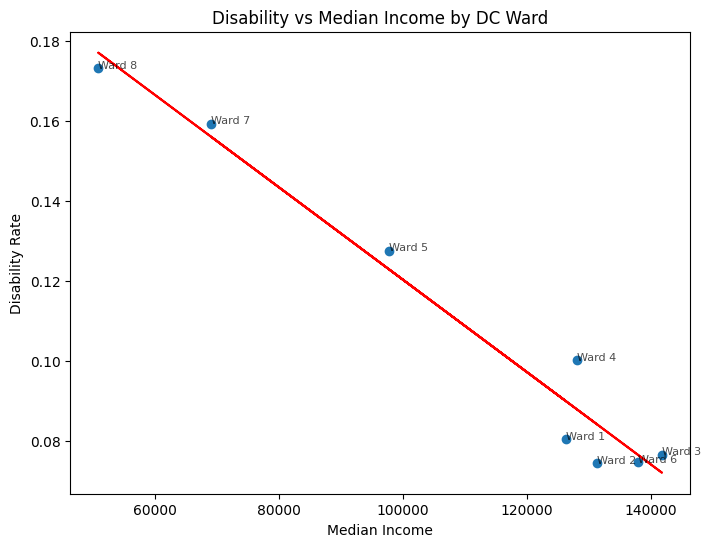

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["median_income"], df["disability_rate"])

m, b = np.polyfit(df["median_income"], df["disability_rate"], 1)
plt.plot(df["median_income"], m*df["median_income"] + b, color="red")

for i in range(len(df)):
    plt.text(df["median_income"].iloc[i],
             df["disability_rate"].iloc[i],
             df["NAMELSAD_x"].iloc[i],
             fontsize=8,
             alpha=0.7)

plt.xlabel("Median Income")
plt.ylabel("Disability Rate")
plt.title("Disability vs Median Income by DC Ward")
plt.show()

I created a scatter plot showing the relationship between unemployment rate and disability rate, added a trend line, and labeled each ward for better clarity. The scatter plot shows a strong positive correlation between unemployment and disability rates across Washington, D.C.'s eight wards. Essentially, in areas where unemployment is higher, the percentage of people living with disabilities also tends to be higher.

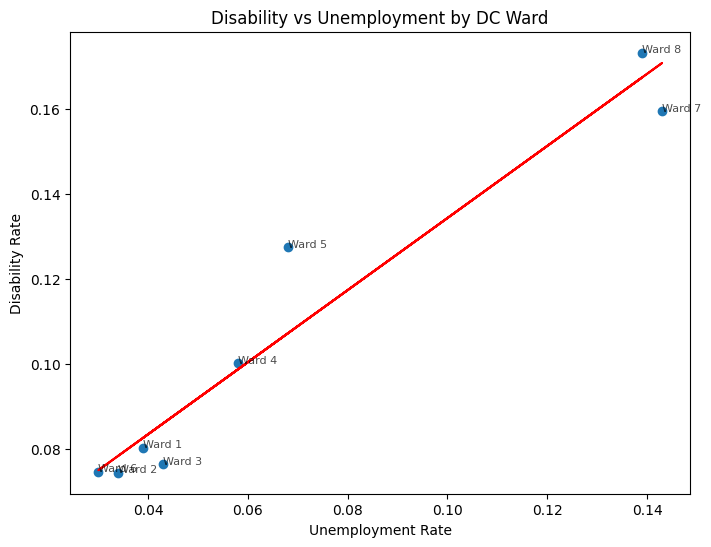

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["unemployment_rate"], df["disability_rate"])

m, b = np.polyfit(df["unemployment_rate"], df["disability_rate"], 1)
plt.plot(df["unemployment_rate"], m*df["unemployment_rate"] + b, color="red")

for i in range(len(df)):
    plt.text(df["unemployment_rate"].iloc[i],
             df["disability_rate"].iloc[i],
             df["NAMELSAD_x"].iloc[i],
             fontsize=8,
             alpha=0.7)

plt.xlabel("Unemployment Rate")
plt.ylabel("Disability Rate")
plt.title("Disability vs Unemployment by DC Ward")
plt.show()

I identified the highest and lowest median income values across all wards and then converted it into a percentage. I did this to better quanitify the level of disapirties between the wards

In [ ]:
highest = df["median_income"].max()
lowest = df["median_income"].min()

In [ ]:
percent_difference = ((highest - lowest) / lowest) * 100
percent_difference

178.51210461212227

I ran a multiple linear regression model to analyze how poverty rate, median income, and unemployment rate together predict disability rates, and printed a full statistical summary of the results. Overall, the regression model explains an extremely high proportion of variation in disability rates across DC wards (R² = 0.989), meaning economic factors together almost fully account for differences in disability prevalence across wards.

In [ ]:
import statsmodels.api as sm

y = df["disability_rate"]

X = df[["poverty_rate", "median_income", "unemployment_rate"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        disability_rate   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     125.5
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           0.000206
Time:                        05:33:50   Log-Likelihood:                 33.120
No. Observations:                   8   AIC:                            -58.24
Df Residuals:                       4   BIC:                            -57.92
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2970      0.06